# Product Review Insights & Issue Detection

## Objective
This notebook identifies the **most common product issues mentioned in customer reviews** by combining:

- Sentiment Analysis
- Topic Modeling
- Review Text Analysis

The goal is to convert raw customer feedback into **actionable business insights**.

In [2]:
import pandas as pd
from collections import Counter

In [3]:
df = pd.read_csv("../data/processed/reviews_with_summaries.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 15)


,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase,text_for_topics,text_for_sentiment,sentiment,predicted_stars,confidence,actual_sentiment,extractive_summary,abstractive_summary
0,1,Bedroom Furniture,DreamRest Memory Foam Mattress,My DreamRest Memory Foam Mattress arrived well...,5,2024-02-08,False,dreamr memory foam mattress arrive package sta...,my dreamrest memory foam mattress arrived well...,Positive,5,0.786409,Positive,My DreamRest Memory Foam Mattress arrived well...,My DreamRest Memory Foam Mattress arrived well...
1,2,Kitchen Appliances,InstaBrew Coffee Maker,The InstaBrew Coffee Maker itself is fine but ...,2,2023-09-11,False,instabrew coffee maker fine packaging complete...,the instabrew coffee maker itself is fine but ...,Negative,2,0.422978,Negative,The InstaBrew Coffee Maker itself is fine but ...,The InstaBrew Coffee Maker itself is fine but ...
2,3,Living Room,GlowLight Floor Lamp,My GlowLight Floor Lamp arrived well packaged ...,5,2023-07-03,False,glowlight floor lamp arrive package start work...,my glowlight floor lamp arrived well packaged ...,Positive,5,0.786339,Positive,My GlowLight Floor Lamp arrived well packaged ...,My GlowLight Floor Lamp arrived well packaged ...
3,4,Living Room,CozySofa L-Shape Sectional,The CozySofa L-Shape Sectional is okay. Does w...,3,2023-06-30,True,cozysofa l shape sectional okay say special av...,the cozysofa l - shape sectional is okay . doe...,Neutral,3,0.820041,Neutral,The CozySofa L-Shape Sectional is okay.,The CozySofa L-Shape Sectional is okay. Does w...
4,5,Kitchen Appliances,TurboBlend Pro 5000,Delivery took 3 weeks and the TurboBlend Pro 5...,3,2024-09-23,True,delivery take 3 week turboblend pro 5000 box c...,delivery took 3 weeks and the turboblend pro 5...,Negative,2,0.406517,Neutral,Delivery took 3 weeks and the TurboBlend Pro 5...,Delivery took 3 weeks and the TurboBlend Pro 5...


In [4]:
df['sentiment'].value_counts()

sentiment
Positive    3499
Negative    1074
Neutral      427
Name: count, dtype: int64

Sentiment Distribution

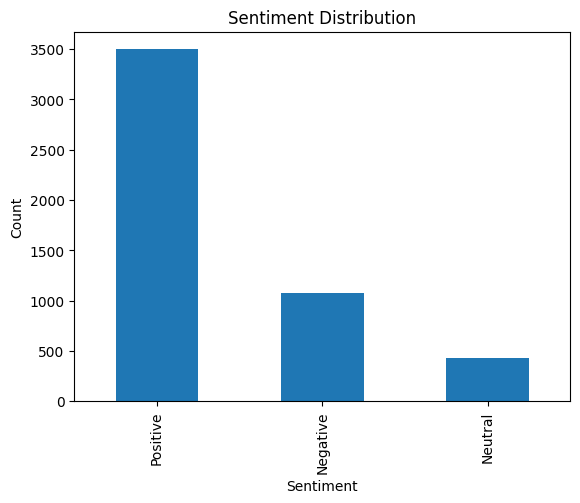

In [5]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [6]:
neg_df = df[df['sentiment'] == 'Negative']

print("Negative Reviews:", len(neg_df))
neg_df.head()

Negative Reviews: 1074


,review_id,product_category,product_name,review_text,star_rating,review_date,verified_purchase,text_for_topics,text_for_sentiment,sentiment,predicted_stars,confidence,actual_sentiment,extractive_summary,abstractive_summary
1,2,Kitchen Appliances,InstaBrew Coffee Maker,The InstaBrew Coffee Maker itself is fine but ...,2,2023-09-11,False,instabrew coffee maker fine packaging complete...,the instabrew coffee maker itself is fine but ...,Negative,2,0.422978,Negative,The InstaBrew Coffee Maker itself is fine but ...,The InstaBrew Coffee Maker itself is fine but ...
4,5,Kitchen Appliances,TurboBlend Pro 5000,Delivery took 3 weeks and the TurboBlend Pro 5...,3,2024-09-23,True,delivery take 3 week turboblend pro 5000 box c...,delivery took 3 weeks and the turboblend pro 5...,Negative,2,0.406517,Neutral,Delivery took 3 weeks and the TurboBlend Pro 5...,Delivery took 3 weeks and the TurboBlend Pro 5...
9,10,Bathroom,FoamPure Electric Toothbrush,<p>Trying to return my FoamPure Electric Tooth...,5,2024-02-15,True,try return foampure electric toothbrush nightm...,trying to return my foampure electric toothbru...,Negative,1,0.877406,Positive,<p>Trying to return my FoamPure Electric Tooth...,<p>Trying to return my FoamPure Electric Tooth...
12,13,Living Room,SmartTV 55in 4K UHD,Very disappointed. The SmartTV 55in 4K UHD arr...,2,2024-06-28,True,disappointed smarttv 55 4k uhd arrive damage s...,very disappointed . the smarttv 55 in 4k uhd a...,Negative,1,0.778265,Negative,The SmartTV 55in 4K UHD arrived damaged and sm...,Very disappointed. The SmartTV 55in 4K UHD arr...
14,15,Bathroom,MirrorPro LED Vanity Mirror,Mixed feelings about the MirrorPro LED Vanity ...,3,2024-12-25,True,mixed feeling mirrorpro lead vanity mirror set...,mixed feelings about the mirrorpro led vanity ...,Negative,2,0.500755,Neutral,Mixed feelings about the MirrorPro LED Vanity ...,Mixed feelings about the MirrorPro LED Vanity ...


In [8]:
issue_topics = (
    neg_df.groupby('topic')
    .size()
    .sort_values(ascending=False)
)

issue_topics

KeyError: 'topic'